Ramen Ratings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# load dataset
data = pd.read_csv('/Users/LX/Desktop/ISDA111_final/ramen-ratings.csv')  

In [2]:
# show the first 10 rows of our data
data.head(10)

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2349,Fantastic,Noodles Chicken & Corn Flavour,Cup,Australia,3,NaN
1,2308,Fantastic,Noodles Chicken Chow Mein Flavour,Cup,Australia,4,NaN
2,2301,Suimin,Noodle With Chicken Flavour,Cup,Australia,3,NaN
3,2296,Suimin,Noodles With Chicken Flavour,Cup,Australia,3,NaN
4,2285,Fantastic,Noodles Beef Flavour,Cup,Australia,3,NaN
5,2274,Suimin,Noodles With Braised Beef Flavour,Cup,Australia,4,NaN
6,2253,Singa-Me,Instant Noodles Mi Goreng Flavour,Cup,Australia,4,NaN
7,2231,Fantastic,Noodle Chicken Flavour,Cup,Australia,4,NaN
8,2219,Fantastic,Noodles Crispy Bacon Flavour,Cup,Australia,1,NaN
9,2188,Singa-Me,Instant Noodles Chicken Flavour,Cup,Australia,2.5,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   object
 2   Variety   2580 non-null   object
 3   Style     2578 non-null   object
 4   Country   2580 non-null   object
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     object
dtypes: int64(1), object(6)
memory usage: 141.2+ KB


In [4]:
# cleaning our data

# clean the 'Stars' column
data['Stars'] = data['Stars'].str.replace(r'[^\d.]+', '')  # remove non-numeric characters
data['Stars'] = pd.to_numeric(data['Stars'], errors='coerce')  # convert to numeric, coerce errors to NaN

<font size="5">1. Which flavors of ramen recieve the highest ratings?</font>

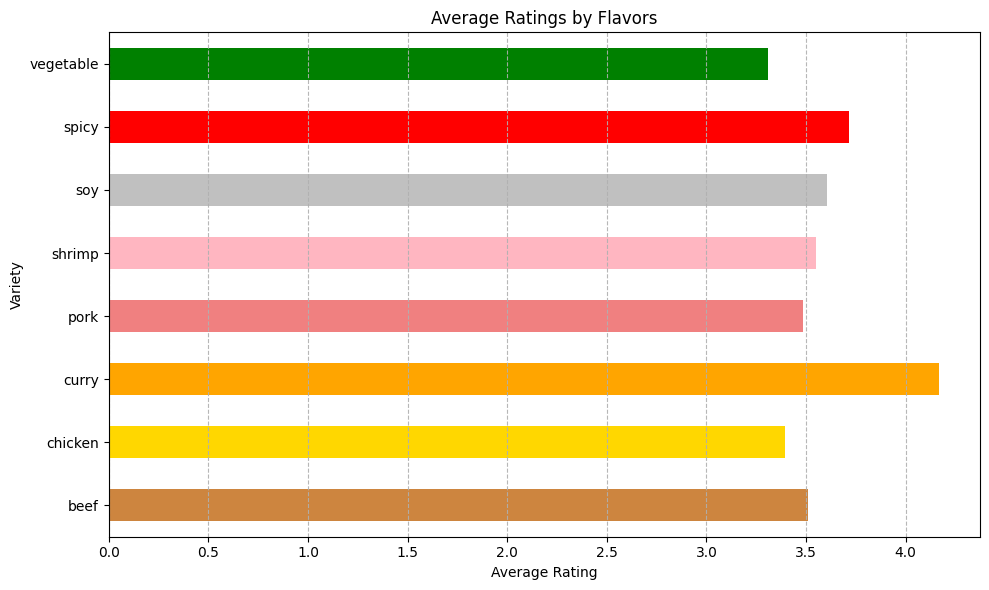

In [5]:
# create library of popular flavors
flavors = ['beef', 'pork', 'chicken', 'shrimp', 'spicy', 'curry', 'vegetable', 'soy']

# function to map variety names to categories
def map_variety(variety):
    for flavor in flavors:
        if flavor in variety.lower():
            return flavor

# apply mapping function to Variety column
data['Category'] = data['Variety'].apply(map_variety)

# calculate each category's average rating
average_ratings = data.groupby('Category')['Stars'].mean()

# apply colors to flavors
colors = {
    "vegetable": "green",
    "chicken": "gold",
    "pork": "lightcoral",
    "beef": "peru",
    "shrimp": "lightpink",
    "spicy": "red",
    "curry": "orange",
    "soy": "silver"
}
 
# plot the bar graph with custom order and colors
plt.figure(figsize=(10, 6))
average_ratings.plot(kind='barh', color=[colors.get(category) for category in average_ratings.index])
plt.xlabel('Average Rating')
plt.ylabel('Variety')
plt.title('Average Ratings by Flavors')
plt.grid(axis='x', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.show()


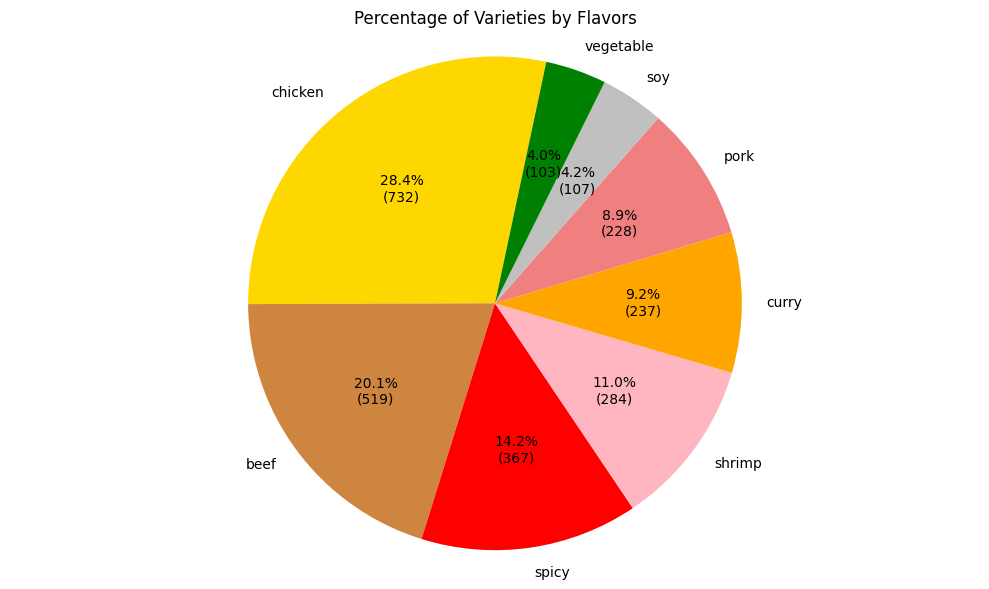

In [6]:
# create library of popular flavors
flavors = ['beef', 'pork', 'chicken', 'shrimp', 'spicy', 'curry', 'vegetable', 'soy']

# function to map variety names to categories
def map_variety(variety):
    for flavor in flavors:
        if flavor in variety.lower():
            return flavor

# apply the mapping function to the Variety column
data['Category'] = data['Variety'].apply(map_variety)

# calculate the count of varieties for each category
variety_count = data['Category'].value_counts()

# calculate the total number of varieties
total_varieties = len(data)

# plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(variety_count, labels=variety_count.index,
        autopct=lambda pct: '{:.1f}%\n({:d})'.format(pct, int(pct/100*total_varieties)),
        startangle=78, colors=[colors.get(category) for category in variety_count.index])
plt.title('Percentage of Varieties by Flavors')
plt.axis('equal')
plt.tight_layout()
plt.show()


<font size="5">2. What are the top five brands that have the most amount of unique ramen varieties?</font>

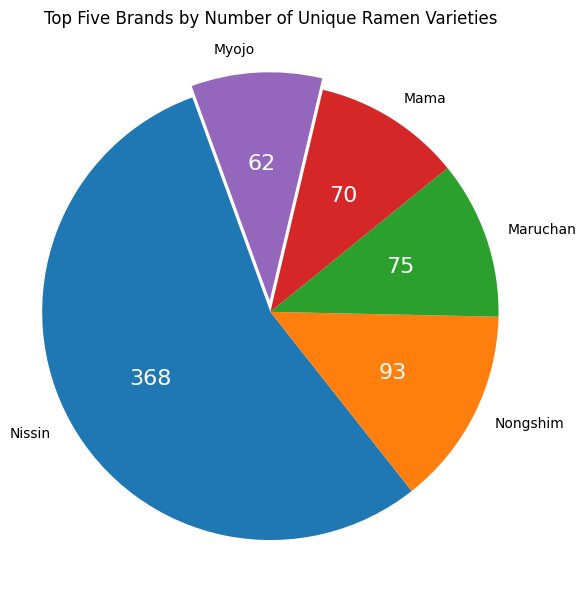

In [7]:
# count the number of unique varieties offered by each brand
variety_counts_by_brand = data.groupby('Brand')['Variety'].nunique()

# find the top five brands with the highest number of unique varieties
dominant_brands = variety_counts_by_brand.nlargest(5)

# plot pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(dominant_brands, labels=dominant_brands.index, 
autopct=lambda pct: f'{int(pct * sum(dominant_brands) / 100)}', startangle=110, explode=[0,0,0,0,0.05])

# customize text properties
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(16)

plt.title('Top Five Brands by Number of Unique Ramen Varieties')
plt.axis('equal')
plt.tight_layout()
plt.show()

<font size="5">3. What is the mean, median, and mode ratings of the top five brands with the most varieties?</font>

<Figure size 1000x600 with 0 Axes>

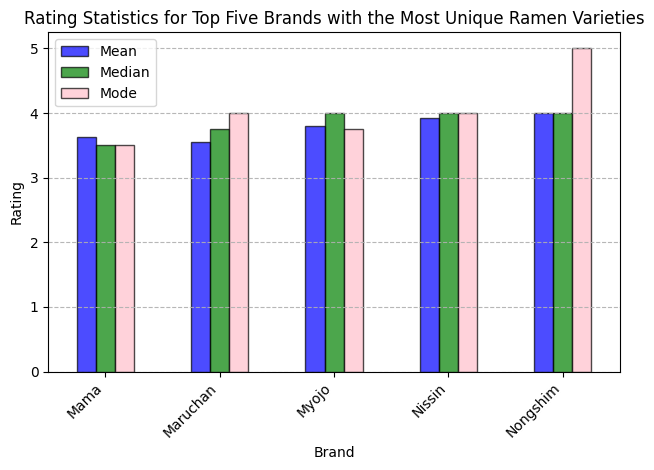

In [8]:
# get top five brands with the most unique ramen varieties
top_five_brands = variety_counts_by_brand.nlargest(5).index

# filter the DataFrame to include only data for the top five brands
df_top_five = data[data['Brand'].isin(top_five_brands)]

# group filtered data by brand and calculate the mean, median, and mode ratings for each brand
rating_stats_by_brand = df_top_five.groupby('Brand')['Stars'].agg(['mean', 'median', lambda x: x.mode().iloc[0]])

# rename lambda function to mode
rating_stats_by_brand.rename(columns={'<lambda>': 'mode'}, inplace=True)

# define custom color palette
colors = ['blue', 'green', 'pink'] 

# plot the average, median, and mode ratings for the top five brands with custom colors
plt.figure(figsize=(10, 6))
rating_stats_by_brand.plot(kind='bar', color=colors, edgecolor='black', alpha=0.7)
plt.title('Rating Statistics for Top Five Brands with the Most Unique Ramen Varieties')
plt.xlabel('Brand')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right') 
plt.legend(['Mean', 'Median', 'Mode'])  
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.show()

<font size="5">4. What is the average ramen rating of the top 100 ratings for countries with at least 100 varieties</font>

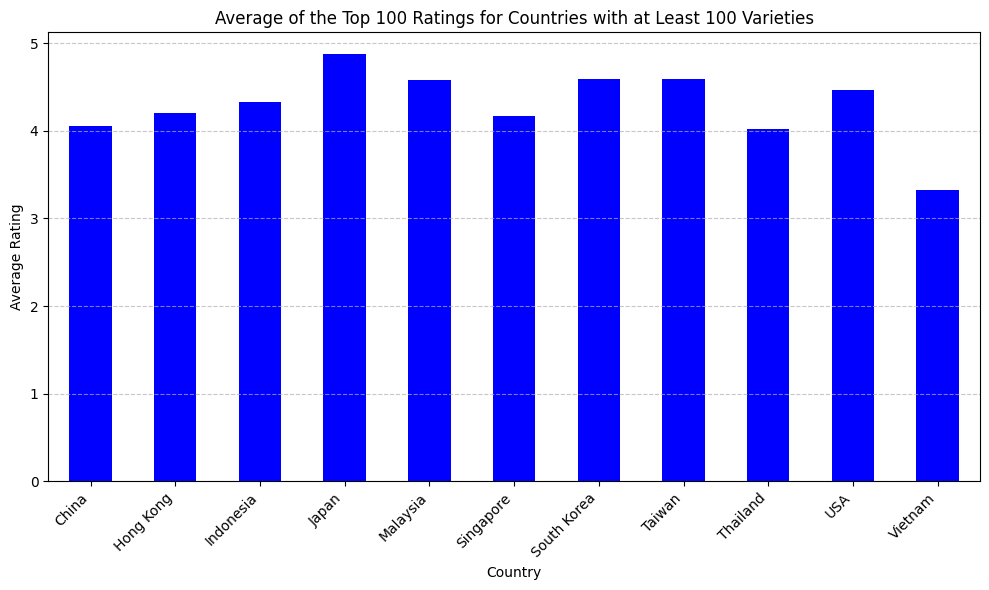

In [9]:
# group data by country and count the number of varieties for each country
country_variety_count = data.groupby('Country')['Variety'].count()

# filter countries with at least 100 varieties
countries_with_100_varieties = country_variety_count[country_variety_count >= 100].index

# filter the dataset to include only countries with at least 100 varieties
df_filtered = data[data['Country'].isin(countries_with_100_varieties)]

# group by country and calculate the average rating for each variety
avg_rating_by_country_variety = df_filtered.groupby(['Country', 'Variety'])['Stars'].mean()

# sort the ratings for each country in descending order and get the top 100 ratings
top_100_ratings_by_country = avg_rating_by_country_variety.groupby('Country', group_keys=False).nlargest(100)

# calculate the average of the top 100 ratings for each country
avg_top_100_ratings_by_country = top_100_ratings_by_country.groupby('Country').mean()

# plot bar plot
plt.figure(figsize=(10, 6))
avg_top_100_ratings_by_country.plot(kind='bar', color='blue')
plt.title('Average of the Top 100 Ratings for Countries with at Least 100 Varieties')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<font size="5">5. What are the ramen styles (packaging) by country?</font>

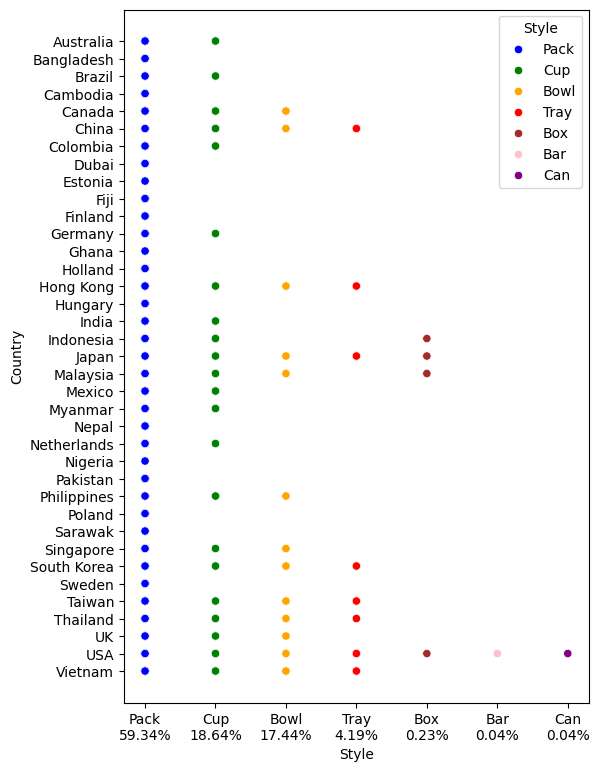

In [10]:
# create dictionary with coordinated colors for each style
style_colors = {'Pack': 'blue', 'Cup': 'green', 'Bowl': 'orange', 'Tray': 'red', 'Can': 'purple', 'Box': 'brown', 'Bar': 'pink'}

# create list order for how styles should appear on the x-axis
style_order = ['Pack', 'Cup', 'Bowl', 'Tray', 'Box', 'Bar', 'Can']

# convert 'Style' column to categorical with specified order
data['Style'] = pd.Categorical(data['Style'], categories=style_order, ordered=True)

style_chart = (6, 9)
fig, ax = plt.subplots(figsize=style_chart)

# use the 'Style' column for x-axis and 'Country' column for y-axis
sns.scatterplot(ax=ax, data=data, y='Country', x='Style', hue='Style', palette=style_colors, legend='brief')

# calculate style percentages
style_counts = data['Style'].value_counts()
total_styles = len(data)
percentages = [f'{(count/total_styles)*100:.2f}%' for count in style_counts]

# set x-axis ticks and labels with percentages
plt.xticks(ticks=range(len(style_order)), labels=[f'{style}\n{percentage}' for style, percentage in zip(style_order, percentages)])

plt.show()